In [50]:
import numpy as np
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout

import matplotlib as mpl
import matplotlib.pyplot as plt
# default font
plt.rcParams['font.size'] = 13

from sklearn.preprocessing import StandardScaler
import pandas as pd
import os

In [51]:
%run useful.py

# training/validation fractions
perc_train = np.arange(0.1, 1, 0.1)
perc_valid = 1 - perc_train

print(perc_valid)

[0.9 0.8 0.7 0.6 0.5 0.4 0.3 0.2 0.1]


(12000, 8)
8
[1.83918812 2.04560279 5.67725029 5.95544703 9.6451452  6.53177097
 7.48906638 6.53569871] 1
[7.47714809 9.61306736 0.08388298 1.06444377 2.98703714 6.56411183
 8.09812553 8.72175914] 0
[9.64647597 7.23685347 6.42475328 7.17453621 4.67599007 3.25584678
 4.39644606 7.29689083] 0
[9.94014586 6.76873712 7.90822518 1.70914258 0.26849276 8.00370244
 9.03722538 0.2467621 ] 0
[4.91747318 5.26255167 5.9636601  0.51957545 8.95089528 7.2826618
 8.18350011 5.00222753] 1
data: 12000
train: [ 1200  2400  3600  4800  6000  7200  8400  9600 10800]
valid: [10800  9600  8400  7200  6000  4800  3599  2399  1199]


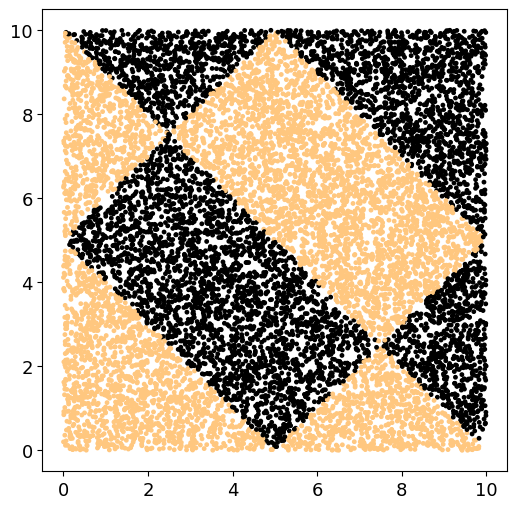

In [52]:
# Keras works with numpy arrays: just use them from the start

TYPE=3
# number of features per sample
L=8
# span of each component
B=10
x = np.loadtxt(filename("data",L,TYPE), delimiter=' ')
y = np.loadtxt(filename("labels",L,TYPE), delimiter=' ')
y = y.astype("int")
print(x.shape)
N = len(x)


# dim. of a sample
L = len(x[0])
print(L)

for i in range(5):
    print(x[i],y[i])

N_train = (perc_train * N).astype(int)
N_valid = (perc_valid * N).astype(int)
print(f'data: {N}\ntrain: {N_train}\nvalid: {N_valid}')

plot_data(x,y)

In [53]:
def Standardize(x,m,s):
    """
    rescale each component using its mean and standard deviation
    x: data points (numpy array)
    m: mean values (numpy array)
    s: standard deviations (numpy array)
    return: rescaled data points (numpy array)
    """
    N = len(x)
    # assuming len(m)=len(s)=len(x[0])
    mm,ss = np.tile(m,(N,1)), np.tile(s,(N,1))
    return (x-mm)/ss

def sets_constructor(N_train, N_valid):

    # split data into train/validation sets and check
    (x_train, y_train) = (x[0:N_train],y[0:N_train])
    (x_valid, y_valid) = (x[N_train:N_train+N_valid],y[N_train:N_train+N_valid])
    print("Train:",len(x_train),"\t Validation:",len(x_valid))


    x_train_mean = np.mean(x_train, axis=0)
    x_train_std = np.std(x_train, axis=0)
    #print("train stats before rescaling:\nmean value=", x_train_mean, "\nstd. dev.=", x_train_std)

    x_valid_mean = np.mean(x_valid, axis=0)
    x_valid_std = np.std(x_valid, axis=0)
    #print("validation stats before rescaling:\nmean value=", x_valid_mean, "\nstd. dev.=", x_valid_std)


    x_train = Standardize(x_train, x_train_mean, x_train_std)
    x_valid = Standardize(x_valid, x_valid_mean, x_valid_std)
    print("after rescaling (train):\nmean value=", x_train.mean(axis=0), "\nstd. dev.=", x_train.std(axis=0))

    return x_train, y_train, x_valid, y_valid, x_train_mean, x_train_std

In [54]:
# reproducibility (?)
np.random.seed(12345)
import tensorflow.random as tf_r
tf_r.set_seed(12345)


n_sets = N_train.size

output_file = "results_2a.csv"
results_list = []

for i in range(n_sets):
    
    x_train, y_train, x_valid, y_valid, _, _= sets_constructor(N_train[i], N_valid[i])

    model = Sequential([
                    Dense(L, input_shape=(L,), activation='relu'),
                    Dense(20, activation='relu'),
                    Dropout(0.1),
                    Dense(20, activation='relu'),
                    Dropout(0.1),
                    Dense(20, activation='relu'),
                    Dropout(0.1),
                    Dense(1, activation='sigmoid')
                ])
    
    model.compile(
        optimizer=keras.optimizers.RMSprop(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy'],
                )
    nepoch=200
    
    fit = model.fit(x_train, y_train,
                epochs = nepoch, batch_size = 50,
                validation_data=(x_valid,y_valid),
                verbose=0)
    
    res = {
        '% training data' : perc_train[i],
        '% validation data' : perc_valid[i],
        'val_loss': fit.history['val_loss'][-1], # Ultimo valore di validation
        'val_accuracy': fit.history['val_accuracy'][-1]
    }
    results_list.append(res)
    pd.DataFrame([res]).to_csv(output_file, mode='a', index=False, header=not os.path.exists(output_file))
    print(f"Completed run {i} of {n_sets-1}")

Train: 1200 	 Validation: 10800
after rescaling (train):
mean value= [-4.95437025e-16 -1.07247544e-15 -3.38895578e-16 -2.44859688e-15
 -7.64666108e-16 -6.57807142e-16 -2.75335310e-16 -2.45729363e-16] 
std. dev.= [1. 1. 1. 1. 1. 1. 1. 1.]


/home/matteocalcagni/Desktop/LCP_B/Labs/DNN/keras_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Completed run 0 of 8
Train: 2400 	 Validation: 9600
after rescaling (train):
mean value= [ 4.01493653e-15  1.01113562e-15  1.39730820e-15 -2.16091034e-15
 -5.25413046e-15 -4.63351579e-15 -1.15124345e-15 -1.47348569e-15] 
std. dev.= [1. 1. 1. 1. 1. 1. 1. 1.]


/home/matteocalcagni/Desktop/LCP_B/Labs/DNN/keras_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Completed run 1 of 8
Train: 3600 	 Validation: 8400
after rescaling (train):
mean value= [-1.11083982e-16  3.22359423e-15 -1.77228602e-15 -2.85210127e-15
 -4.40070819e-15 -3.43271707e-15 -2.39968539e-15 -1.40911973e-15] 
std. dev.= [1. 1. 1. 1. 1. 1. 1. 1.]


...

Completed run 6 of 8
Train: 9600 	 Validation: 2399
after rescaling (train):
mean value= [ 2.03108363e-15  6.29479108e-15 -5.69839315e-15 -5.48011867e-15
 -4.38954428e-15 -3.07013674e-15 -4.04352477e-16 -1.01049493e-14] 
std. dev.= [1. 1. 1. 1. 1. 1. 1. 1.]


/home/matteocalcagni/Desktop/LCP_B/Labs/DNN/keras_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Completed run 7 of 8
Train: 10800 	 Validation: 1199
after rescaling (train):
mean value= [ 1.91540199e-15  7.85519797e-15 -4.43082299e-15 -4.90277572e-15
 -4.45316366e-15 -2.19519876e-15  4.39740836e-16 -7.81854005e-15] 
std. dev.= [1. 1. 1. 1. 1. 1. 1. 1.]


/home/matteocalcagni/Desktop/LCP_B/Labs/DNN/keras_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Completed run 8 of 8


In [55]:
#Retrain the best setup for the plot
x_train, y_train, x_valid, y_valid, x_train_mean, x_train_std = sets_constructor(N_train[5], N_valid[5])

model = Sequential([
                    Dense(L, input_shape=(L,), activation='relu'),
                    Dense(20, activation='relu'),
                    Dropout(0.1),
                    Dense(20, activation='relu'),
                    Dropout(0.1),
                    Dense(20, activation='relu'),
                    Dropout(0.1),
                    Dense(1, activation='sigmoid')
                ])
    
model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy'],
            )
nepoch=200

fit = model.fit(x_train, y_train,
            epochs = nepoch, batch_size = 50,
            validation_data=(x_valid,y_valid),
            verbose=2)

Train: 7200 	 Validation: 4800
after rescaling (train):
mean value= [ 4.97429258e-15  7.58550630e-15 -3.36221791e-15 -1.12749316e-16
 -3.14578610e-15 -2.87425947e-15 -2.72715492e-15 -2.54271912e-15] 
std. dev.= [1. 1. 1. 1. 1. 1. 1. 1.]
Epoch 1/200


/home/matteocalcagni/Desktop/LCP_B/Labs/DNN/keras_env/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


144/144 - 1s - 9ms/step - accuracy: 0.5274 - loss: 0.6878 - val_accuracy: 0.5337 - val_loss: 0.6793
Epoch 2/200
144/144 - 1s - 4ms/step - accuracy: 0.5374 - loss: 0.6745 - val_accuracy: 0.5498 - val_loss: 0.6651
Epoch 3/200
144/144 - 1s - 4ms/step - accuracy: 0.5522 - loss: 0.6604 - val_accuracy: 0.5804 - val_loss: 0.6486
Epoch 4/200
144/144 - 1s - 4ms/step - accuracy: 0.5811 - loss: 0.6415 - val_accuracy: 0.5962 - val_loss: 0.6306
Epoch 5/200
144/144 - 1s - 4ms/step - accuracy: 0.6122 - loss: 0.6253 - val_accuracy: 0.6279 - val_loss: 0.6111
Epoch 6/200
144/144 - 1s - 4ms/step - accuracy: 0.6351 - loss: 0.6099 - val_accuracy: 0.6585 - val_loss: 0.5928
Epoch 7/200
144/144 - 1s - 5ms/step - accuracy: 0.6572 - loss: 0.5930 - val_accuracy: 0.6852 - val_loss: 0.5704
Epoch 8/200
144/144 - 1s - 4ms/step - accuracy: 0.6712 - loss: 0.5740 - val_accuracy: 0.6942 - val_loss: 0.5524
Epoch 9/200
144/144 - 1s - 4ms/step - accuracy: 0.6918 - loss: 0.5583 - val_accuracy: 0.7102 - val_loss: 0.5344
Epoc

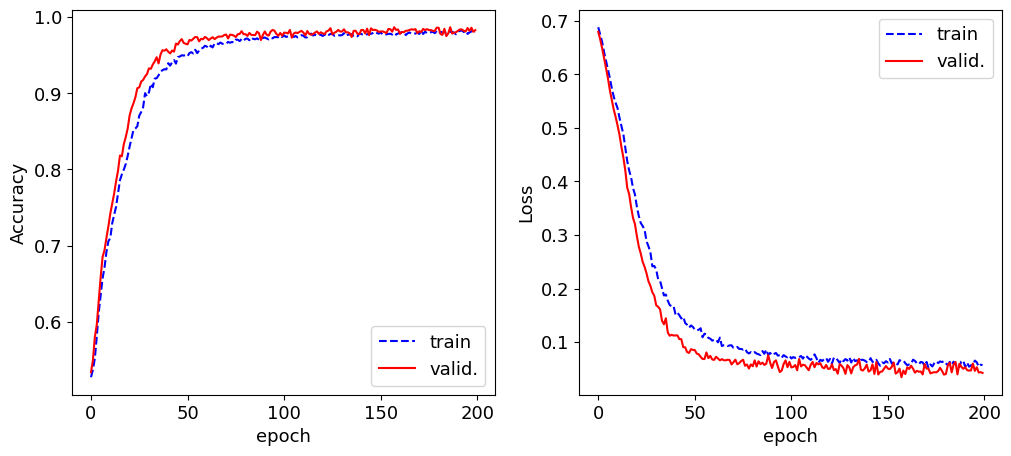

In [56]:
fig,AX=plt.subplots(1,2,figsize=(12,5.))
ax=AX[0]
ax.plot(fit.history['accuracy'],label="train",c="b",ls="--")
ax.plot(fit.history['val_accuracy'],label="valid.",c="r")
ax.set_xlabel('epoch')
ax.set_ylabel("Accuracy")
ax.legend()
ax=AX[1]
ax.plot(fit.history['loss'],label="train",c="b",ls="--")
ax.plot(fit.history['val_loss'],label="valid.",c="r")
ax.set_xlabel('epoch')
ax.set_ylabel("Loss")
ax.legend()

319/319 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


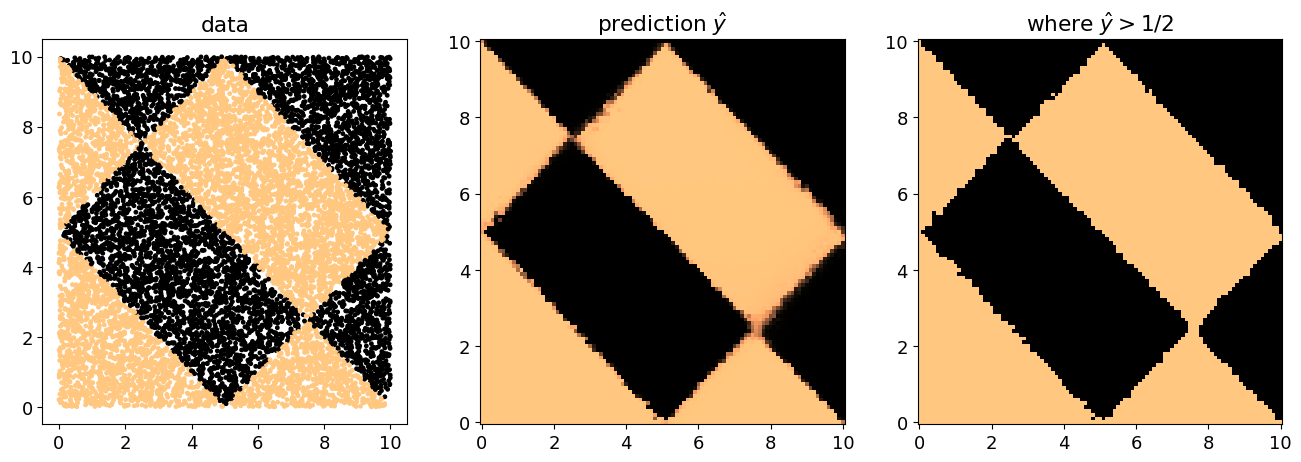

remember: these are 2 out of L=8 dimensions, of which L-2 contain random noise


In [57]:
dX = .1
X1 = np.arange(0,10+dX, dX)
LG = len(X1)
# 2D meshgrid
X, Y = np.meshgrid(X1, X1)
allXY = np.reshape((np.array((X,Y)).T),(LG**2,2))
#create synthetic inputs with L features for each grid point; initialized randomly in [0, B].
grid = np.random.rand(LG**2,L)*B
#replace first 2 features with the actual 2D coordinates
grid[:,:2] = allXY
#standardize using train-set mean/std before prediction
grid_r=Standardize(grid,x_train_mean,x_train_std)

pred = model.predict(grid_r)

fig,AX=plt.subplots(1,3,figsize=(16,5.))
ax=AX[0]
ax.scatter(x[:,0],x[:,1],c=y,s=6)
ax.set_title("data")
ax=AX[1]
ax.pcolormesh(X1,X1,pred.reshape((LG, LG)))
ax.set_title("prediction $\\hat y$")
ax=AX[2]
pred01=np.copy(pred)
pred01[pred>0.5]=1
pred01[pred<=0.5]=0
ax.pcolormesh(X1,X1,pred01.reshape((LG, LG)))
ax.set_title("where $\\hat y > 1/2$")
plt.show()
print(f"remember: these are 2 out of L={L} dimensions, of which L-2 contain random noise")